# Question 1

Which loss function you will use?

* nn.MSELoss()
* **nn.BCEWithLogitsLoss()**
* nn.CrossEntropyLoss()
* nn.CosineEmbeddingLoss()

(Multiple answered can be correct, so pick any)

## Get the Data

In [1]:
!wget https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip

--2025-11-29 09:20:25--  https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/405934815/e712cf72-f851-44e0-9c05-e711624af985?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-29T10%3A17%3A01Z&rscd=attachment%3B+filename%3Ddata.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-29T09%3A16%3A18Z&ske=2025-11-29T10%3A17%3A01Z&sks=b&skv=2018-11-09&sig=2j5iQlp2TvnUTj14gnBOFgzFkk2TtFCY9fcZ42k7Y%2FY%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2NDQwOTgyNSwibmJmIjoxNzY0NDA4MDI1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5i

In [2]:
!unzip data.zip

Archive:  data.zip
   creating: data/
   creating: data/test/
   creating: data/test/curly/
  inflating: data/test/curly/03312ac556a7d003f7570657f80392c34.jpg  
  inflating: data/test/curly/106dfcf4abe76990b585b2fc2e3c9f884.jpg  
  inflating: data/test/curly/1a9dbe23a0d95f1c292625960e4509184.jpg  
  inflating: data/test/curly/341ea26e6677b655f8447af56073204a4.jpg  
  inflating: data/test/curly/61aPFVrm42L._SL1352_.jpg  
  inflating: data/test/curly/6d8acb0fe980774ea4e5631198587f45.png  
  inflating: data/test/curly/7f5649a0c33a2b334f23221a52c16b9b.jpg  
  inflating: data/test/curly/90146673.jpg  
  inflating: data/test/curly/9b3608e01d78fbabc9fb0719323d507f4.jpg  
  inflating: data/test/curly/b171c99161f3cffc12d4b74488ef2fc6.jpg  
  inflating: data/test/curly/blogger_one.jpg  
  inflating: data/test/curly/c03ca1590aa4df74e922ad8257305a2b.jpg  
  inflating: data/test/curly/c1b89bb4f86a3478ec20ce1f63f003c1.jpg  
  inflating: data/test/curly/c5.jpg  
  inflating: data/test/curly/C86_76156

In [3]:
import numpy as np
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
print(torch.__version__)

2.9.0+cu126


In [5]:
from PIL import Image
import numpy as np

In [6]:
img = Image.open('/content/data/train/straight/03e7316208c63582103294f3e1ef8b7b.jpg')

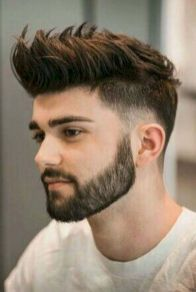

In [ ]:
img

In [ ]:
print(img.size)

(196, 292)


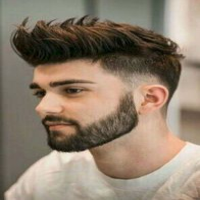

In [ ]:
img.resize((200, 200))

## Define Model Architecture

To create the PyTorch model as specified, we will define a class HairClassifier that inherits from torch.nn.Module, implement its `__init__` and forward methods with the required layers, and then instantiate it.


In [7]:
import torch.nn as nn # Stateful Layers/learnable parameters (nn.Linear, nn.Conv2d, nn.BatchNorm2d, nn.Dropout, etc.)
import torch.nn.functional as F # Stateless Operations (F.relu, F.sigmoid, F.max_pool2d, F.mse_loss, F.binary_cross_entropy)

class HairClassifier(nn.Module):
    def __init__(self):
        # Call methods defined in the parent/superclass
        super(HairClassifier, self).__init__()
        # Convolutional layer: 3 (200x200) input channels (for RGB image), 32 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=(3, 3))
        # Max pooling layer: 2x2 kernel
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))

        # Calculate the flattened size after the first conv and pool for a 200x200 input image:
        #   After conv1 (kernel 3x3, no padding): 200 - 3 + 1 = 198 possible starting positions
        #   After pool (kernel 2x2): 198 / 2 = 99 possible starting positions
        #   So, the flattened size with 32 channels will be 32 * 99 * 99
        self.flattened_size = 32 * 99 * 99

        # Linear/Dense layer: 64 neurons
        self.dense1 = nn.Linear(self.flattened_size, 64)
        # Output linear layer: 1 neuron
        self.dense2 = nn.Linear(64, 1)

    def forward(self, x):
        # Convolutions stack multiple linear layers.
        # We add non-linear 'relu' activation in between layers,
        # so the stack doesn't behave like a single linear layer.
        x = F.relu(self.conv1(x)) # Introduce non-linearity
        x = self.pool(x)
        x = x.view(-1, self.flattened_size) # "-1" automatically calculates the dimension size
        # Apply first linear layer and ReLU activation
        x = F.relu(self.dense1(x))
        # Apply second linear layer (outputting logits for BCEWithLogitsLoss)
        x = self.dense2(x)
        return x

# Instantiate the model
model = HairClassifier()

# Define the optimizer (already done in a separate cell, but kept here if needed)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)

print("Model Architecture:")
print(model)

Model Architecture:
HairClassifier(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dense1): Linear(in_features=313632, out_features=64, bias=True)
  (dense2): Linear(in_features=64, out_features=1, bias=True)
)


## Define Optimizer and Loss

Define the optimizer using `torch.optim.SGD` with `model.parameters()`, learning rate `0.002`, and momentum `0.8`.

To correctly use nn.BCEWithLogitsLoss(), the model should output raw logits (i.e., without a final sigmoid activation).

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)
criterion = nn.BCEWithLogitsLoss()
print("\nOptimizer Configuration:")
print(optimizer)
print("\nLoss Function:")
print(criterion)


Optimizer Configuration:
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.002
    maximize: False
    momentum: 0.8
    nesterov: False
    weight_decay: 0
)

Loss Function:
BCEWithLogitsLoss()


# Question 2
What's the total number of parameters of the model? You can use torchsummary or count manually.

### Option 2: Manual counting
`total_params = sum(p.numel() for p in model.parameters())`

`print(f"Total parameters: {total_params}")`

* 896
* 11214912
* 15896912
* **20073473**

In [9]:
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#dummy_input = torch.randn(1, 3, 200, 200).to(device)

# Ensure the model is also on the correct device before calling summary
model.to(device)
summary(model, input_size=(3, 200, 200), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 198, 198]             896
         MaxPool2d-2           [-1, 32, 99, 99]               0
            Linear-3                   [-1, 64]      20,072,512
            Linear-4                    [-1, 1]              65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.46
Forward/backward pass size (MB): 11.96
Params size (MB): 76.57
Estimated Total Size (MB): 89.00
----------------------------------------------------------------


# Question 3
What is the median of training accuracy for all the epochs for this model?

* 0.05
* 0.12
* 0.40
* **0.84**

## Custom Dataset Class

Create a PyTorch Dataset to load images.

In [10]:
import os
from torch.utils.data import Dataset
from PIL import Image

class HairDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## Preprocessing
Rerun for questions 5 and 6.

In [23]:
from torchvision import transforms

input_size = 200

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Add augmentations to train_transforms for question 5 and 6
train_transforms = transforms.Compose([
    #transforms.Resize((input_size, input_size)), # RandomResizedCrop handles resizing
    transforms.RandomRotation(50),
    transforms.RandomResizedCrop(input_size, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

## Create DataLoaders
Rerun for questions 5 and 6. The train_loader object was created before enabling augmentations. The train_loader should be re-run so that it uses the updated train_transforms with augmentations.

In [25]:
from torch.utils.data import DataLoader

train_dataset = HairDataset(
    data_dir='/content/data/train',
    transform=train_transforms
)

test_dataset = HairDataset(
    data_dir='/content/data/test',
    transform=test_transforms
)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)

## Train the Model

In [13]:
import torch.optim as optim

# The T4 GPU will be understood as CUDA-enabled by PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HairClassifier()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

In [14]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(test_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch 1/10, Loss: 28.5704, Acc: 0.5968, Val Loss: 4.8141, Val Acc: 0.5423
Epoch 2/10, Loss: 0.7949, Acc: 0.7303, Val Loss: 0.6626, Val Acc: 0.6866
Epoch 3/10, Loss: 0.3544, Acc: 0.8315, Val Loss: 0.6085, Val Acc: 0.7413
Epoch 4/10, Loss: 0.1839, Acc: 0.9376, Val Loss: 0.6238, Val Acc: 0.7711
Epoch 5/10, Loss: 0.1406, Acc: 0.9538, Val Loss: 0.9267, Val Acc: 0.7264
Epoch 6/10, Loss: 0.1022, Acc: 0.9725, Val Loss: 0.6358, Val Acc: 0.7811
Epoch 7/10, Loss: 0.0380, Acc: 0.9950, Val Loss: 0.7490, Val Acc: 0.7960
Epoch 8/10, Loss: 0.0191, Acc: 1.0000, Val Loss: 0.7832, Val Acc: 0.7811
Epoch 9/10, Loss: 0.0099, Acc: 1.0000, Val Loss: 0.8628, Val Acc: 0.7612
Epoch 10/10, Loss: 0.0068, Acc: 1.0000, Val Loss: 0.8955, Val Acc: 0.7662


## The Training Accuracy Median

In [15]:
import numpy as np

# Access 'history' dictionary
train_accuracies = history['acc']
train_losses = history['loss']

# Convert lists to PyTorch tensors
accuracy_tensor = torch.tensor(train_accuracies)
loss_tensor = torch.tensor(train_losses)

# Calculate median of training accuracy
median_accuracy = torch.median(accuracy_tensor)

# Calculate standard deviation of training loss
std_loss = torch.std(loss_tensor)

print(f"Median of training accuracy (using torch): {median_accuracy.item():.4f}")
print(f"Standard deviation of training loss (using torch): {std_loss.item():.4f}")

# Verify against numpy
print(f"Median of training accuracy (using numpy): {np.median(train_accuracies):.4f}")
print(f"Standard deviation of training loss (using numpy): {np.std(train_losses):.4f}")

Median of training accuracy (using torch): 0.9538
Standard deviation of training loss (using torch): 8.9800
Median of training accuracy (using numpy): 0.9632
Standard deviation of training loss (using numpy): 8.5192


In [17]:
# Sort to calculate the median of an even list
sorted(history['acc'])

[0.5967540574282147,
 0.7303370786516854,
 0.8314606741573034,
 0.9375780274656679,
 0.9538077403245943,
 0.9725343320848939,
 0.9950062421972534,
 1.0,
 1.0,
 1.0]

In [18]:
# Calculate the average of the two middle values
(0.9538077403245943 +  0.9725343320848939) / 2

0.9631710362047441

# Question 4
What is the standard deviation of training loss for all the epochs for this model?

* 0.007
* 0.078
* 0.171
* **1.710**

In [21]:
# List of training loss values
loss_values = history['loss']

# Calculate the mean (average)
mean_loss = sum(loss_values) / len(loss_values)
print(f"Mean of loss values: {mean_loss:.4f}")

# Calculate the squared differences from the mean
squared_differences = []
for x_i in loss_values:
    diff = x_i - mean_loss
    squared_diff = diff ** 2
    squared_differences.append(squared_diff)
print(f"Squared differences: {squared_differences}")

# Sum up all these squared differences
sum_squared_differences = sum(squared_differences)
print(f"Sum of squared differences: {sum_squared_differences:.4f}")

# Divide by the total number of data points (N) to get the variance
N = len(loss_values)
variance = sum_squared_differences / N
print(f"Variance: {variance:.4f}")

# Take the square root of the variance to get the standard deviation
standard_deviation = variance ** 0.5 # or variance**(1/2) or math.sqrt(variance)
print(f"Standard Deviation: {standard_deviation:.4f}")

Mean of loss values: 3.0220
Squared differences: [652.7197479710212, 4.960031794133847, 7.116059223132469, 8.055101019412707, 8.302667314190394, 8.52521569873475, 8.904431661139693, 9.017395017123526, 9.073125977195799, 9.091431268216663]
Sum of squared differences: 725.7652
Variance: 72.5765
Standard Deviation: 8.5192


In [22]:
# The standard deviation excluding the high loss value from the first epoch
train_losses = history['loss']

# Exclude the first epoch's loss
losses_without_first_epoch = train_losses[1:]

# Convert to PyTorch tensor
loss_tensor_filtered = torch.tensor(losses_without_first_epoch)

# Calculate the standard deviation
std_loss_filtered = torch.std(loss_tensor_filtered)

print(f"Standard deviation of training loss (excluding first epoch): {std_loss_filtered.item():.4f}")

Standard deviation of training loss (excluding first epoch): 0.2552


## Question 5
Let's train our model for 10 more epochs using the same code as previously.

Note: make sure you don't re-create the model. we want to continue training the model we already started training.

What is the mean of test loss for all the epochs for the model trained with augmentations?

* 0.008
* 0.08
* **0.88**
* 8.88

In [26]:
# Train for 10 more epochs
num_additional_epochs = 10

print(f"Continuing training for {num_additional_epochs} additional epochs...")

for epoch in range(num_additional_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(test_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {len(history['val_loss'])}/{len(history['val_loss'])-1 + num_additional_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

print("Training finished.")

Continuing training for 10 additional epochs...
Epoch 11/20, Loss: 1.1067, Acc: 0.6404, Val Loss: 0.6302, Val Acc: 0.6418
Epoch 12/21, Loss: 0.5950, Acc: 0.7054, Val Loss: 0.5684, Val Acc: 0.6965
Epoch 13/22, Loss: 0.5635, Acc: 0.7203, Val Loss: 0.6005, Val Acc: 0.6766
Epoch 14/23, Loss: 0.5384, Acc: 0.7566, Val Loss: 0.6878, Val Acc: 0.6567
Epoch 15/24, Loss: 0.4975, Acc: 0.7591, Val Loss: 0.5225, Val Acc: 0.7612
Epoch 16/25, Loss: 0.4974, Acc: 0.7615, Val Loss: 0.6931, Val Acc: 0.6766
Epoch 17/26, Loss: 0.4682, Acc: 0.7903, Val Loss: 0.5798, Val Acc: 0.7363
Epoch 18/27, Loss: 0.4599, Acc: 0.7765, Val Loss: 0.5129, Val Acc: 0.7612
Epoch 19/28, Loss: 0.4679, Acc: 0.7890, Val Loss: 0.5514, Val Acc: 0.7015
Epoch 20/29, Loss: 0.4481, Acc: 0.7903, Val Loss: 0.5776, Val Acc: 0.7363
Training finished.


In [27]:
# Calculate the mean of all test losses from the history
all_val_losses = history['val_loss']
mean_test_loss = torch.tensor(all_val_losses).mean()

print(f"Mean of test loss for all epochs (including augmentations): {mean_test_loss.item():.4f}")


Mean of test loss for all epochs (including augmentations): 0.8743


## Question 6
What's the average of test accuracy for the last 5 epochs (from 6 to 10) for the model trained with augmentations?

* 0.08
* 0.28
* **0.68**
* 0.98

In [28]:
# Get all validation accuracies from the history
all_val_accuracies = history['val_acc']

# Extract the last 5 validation accuracies (epochs 16 to 20) with Python list slicing
last_5_val_accuracies = all_val_accuracies[-5:]

# Convert to a PyTorch tensor and calculate the mean
average_test_accuracy = torch.tensor(last_5_val_accuracies).mean()

print(f"Average of test accuracy for the last 5 augmented epochs: {average_test_accuracy.item():.4f}")

Average of test accuracy for the last 5 augmented epochs: 0.7224
